# 09a — Multi-Outcome CATE Analysis (SP4 Part A)

**Task 3.1**: Surplus 중심 multi-outcome CATE — bid elasticity, cost elasticity, mediation 분해.

## Key Results

| Outcome | ATE | 95% CI | Interpretation |
|---------|-----|--------|----------------|
| Win     | TBD | TBD    | bid 277→294 시 win rate 변화 |
| Payment | TBD | TBD    | bid 증가 시 payment 변화 (winners-only) |
| Click   | TBD | TBD    | bid→click 직접 효과 (예상: ~0) |
| Surplus | TBD | TBD    | 순경제 효과 |

**Mediation**: NIE (volume) TBD% vs NDE (cost) TBD%

**Core insight**: [실행 후 채움]

**Pipeline**: SP1 (debiased pCTR) → SP2 (market CDF) → SP3 (bid optimization) → **SP4 (causal)**

**Treatment identification**: iPinYou flat-bid → S3에서 T ∈ {277, 294} binary treatment only.
V(x)는 CATE outcome 불가 (bid-invariant model prediction, ∂V/∂bid = 0).

## Section 0: Setup & Data Loading

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path('.').absolute().parent
sys.path.insert(0, str(PROJECT_ROOT))

RESULTS_PATH = PROJECT_ROOT / 'results'
FIG_PATH = RESULTS_PATH / 'figures'
DATA_PATH = PROJECT_ROOT / 'data' / 'ipinyou' / 'prediction' / 'features'
MODEL_PATH = RESULTS_PATH / 'models'

FIG_PATH.mkdir(parents=True, exist_ok=True)
warnings.filterwarnings('ignore', category=FutureWarning)

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 150, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.labelsize': 11})
PALETTE = sns.color_palette('Set2', 8)

from src.causal.cate import (
    CATEConfig, prepare_cate_data, estimate_cate,
    validate_decomposition, estimate_mediation, compute_segment_cate_summary,
    assign_advertiser_taxonomy, ADVERTISER_TAXONOMY,
)
from src.bidding.value import ValueConfig, compute_impression_values

from econml.dr import ForestDRLearner
from lightgbm import LGBMClassifier, LGBMRegressor

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/taehyun/project/rtb_ipinyou


In [3]:
# --- Test set (S3) ---
COLS = ['bidprice', 'payprice', 'slotprice', 'adexchange', 'hour', 'region',
        'win', 'click', 'advertiser', 'slot_area', 'domain_freq']
test_df = pd.read_parquet(DATA_PATH / 'test.parquet', columns=COLS)

# --- ESCM2-WC(DR) predictions ---
preds = dict(np.load(MODEL_PATH / 'escm2wc_dr_test_predictions.npz'))

print(f"Test set: {len(test_df):,} rows")
print(f"Predictions: {list(preds.keys())}")
print(f"Bid prices: {sorted(test_df['bidprice'].unique())}")
print(f"Advertisers: {sorted(test_df['advertiser'].unique())}")
print(f"Win rate: {test_df['win'].mean():.3f}")

Test set: 19,424,025 rows
Predictions: ['p_win', 'p_ctr', 'p_click_bid', 'y_win', 'y_click']
Bid prices: [277, 294]
Advertisers: [2259, 2261, 2821, 2997]
Win rate: 0.218


## Section 1: Treatment Identification Problem

iPinYou는 advertiser별 flat-bid 구조 — 연속 treatment 가정 위반.
CausalForestDML `discrete_treatment=True`로 전환, variation 없는 advertiser 제외.

In [4]:
# --- Advertiser × Bid crosstab: S2 (Train) vs S3 (Test) ---
train_bid = pd.read_parquet(DATA_PATH / 'train.parquet', columns=['bidprice', 'advertiser'])

ct_train = pd.crosstab(train_bid['advertiser'], train_bid['bidprice'])
ct_test = pd.crosstab(test_df['advertiser'], test_df['bidprice'])

print("=== Train (S2): Advertiser × Bid ===")
display(ct_train)
print("\n=== Test (S3): Advertiser × Bid ===")
display(ct_test)

del train_bid

# --- Per-advertiser variation ---
print("\n=== Treatment Variation Summary ===")
for label, ct in [("S2", ct_train), ("S3", ct_test)]:
    for adv in ct.index:
        used = ct.loc[adv][ct.loc[adv] > 0].index.tolist()
        taxonomy = assign_advertiser_taxonomy(np.array([adv]))[0]
        print(f"  {label} Adv {adv} ({taxonomy}): {len(used)} levels = {used}")

=== Train (S2): Advertiser × Bid ===


bidprice,227,238,241,249,254,300
advertiser,,,,,,
1458,0,0,0,0,0,24603894
3358,2512110,1888848,1125450,0,0,0
3386,0,0,0,0,0,23163967
3427,1775338,13436724,9915498,0,0,0
3476,0,1688762,0,1940304,8594553,0



=== Test (S3): Advertiser × Bid ===


bidprice,277,294
advertiser,,
2259,1278288,2505842
2261,1302240,3017176
2821,1474490,7810135
2997,2035854,0



=== Treatment Variation Summary ===
  S2 Adv 1458 (branding): 1 levels = [300]
  S2 Adv 3358 (retargeting): 3 levels = [227, 238, 241]
  S2 Adv 3386 (branding): 1 levels = [300]
  S2 Adv 3427 (branding): 3 levels = [227, 238, 241]
  S2 Adv 3476 (mixed): 3 levels = [238, 249, 254]
  S3 Adv 2259 (retargeting): 2 levels = [277, 294]
  S3 Adv 2261 (branding): 2 levels = [277, 294]
  S3 Adv 2821 (retargeting): 2 levels = [277, 294]
  S3 Adv 2997 (branding): 1 levels = [277]


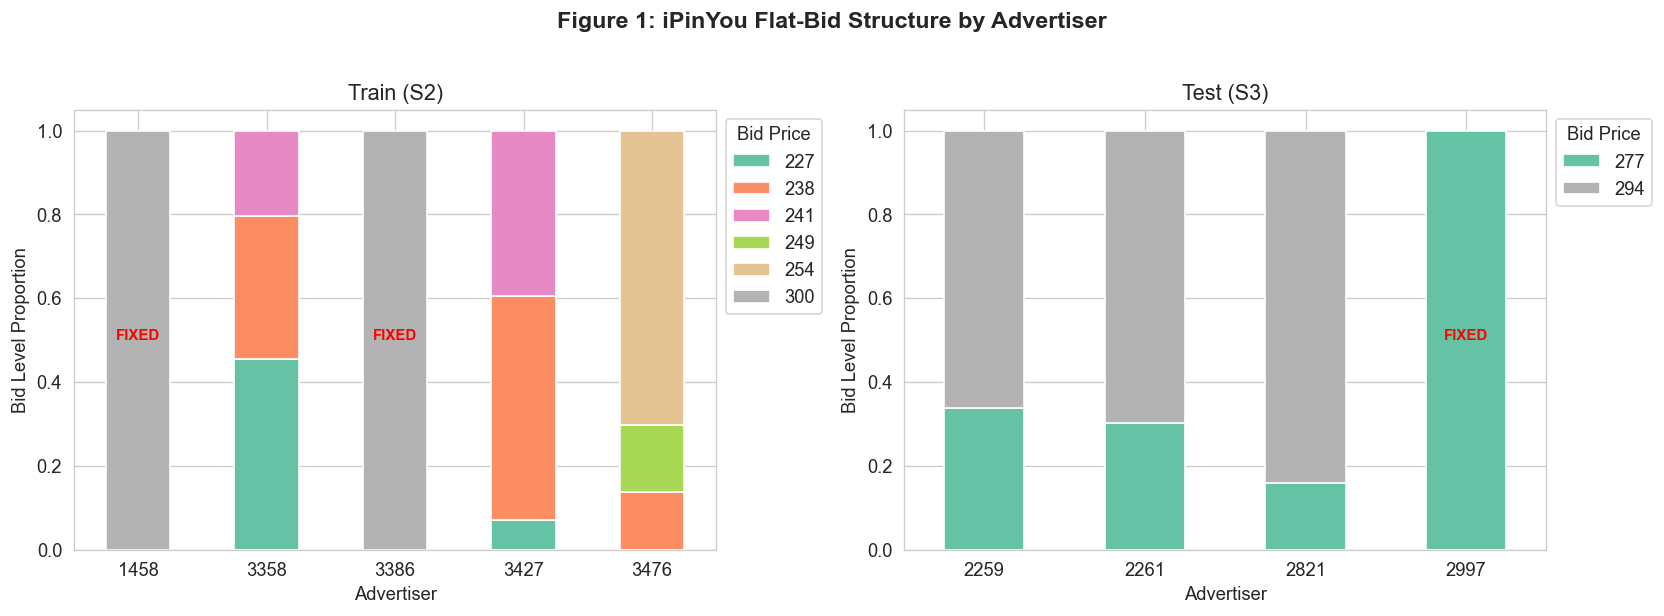

결론: S3에서 adv 2997(bid=277 고정) 제외 → T ∈ {277, 294} binary treatment


In [5]:
# --- Figure 1: iPinYou Flat-Bid Structure ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ct, title in [(axes[0], ct_train, 'Train (S2)'), (axes[1], ct_test, 'Test (S3)')]:
    ct_plot = ct.div(ct.sum(axis=1), axis=0)  # normalize to proportions
    ct_plot.plot(kind='bar', stacked=True, ax=ax, colormap='Set2', edgecolor='white')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Advertiser')
    ax.set_ylabel('Bid Level Proportion')
    ax.legend(title='Bid Price', bbox_to_anchor=(1.0, 1.0))
    ax.tick_params(axis='x', rotation=0)

    # Annotate fixed-bid advertisers
    for i, adv in enumerate(ct.index):
        n_levels = (ct.loc[adv] > 0).sum()
        if n_levels == 1:
            ax.annotate('FIXED', (i, 0.5), ha='center', fontsize=9,
                        fontweight='bold', color='red')

fig.suptitle('Figure 1: iPinYou Flat-Bid Structure by Advertiser',
             fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(FIG_PATH / '09a_treatment_variation_crosstab.png', dpi=150, bbox_inches='tight')
plt.show()

print("결론: S3에서 adv 2997(bid=277 고정) 제외 → T ∈ {277, 294} binary treatment")

## Section 2: Data Preparation

Filter to advertisers with bid variation, compute V(x), prepare CATE arrays.
Binary treatment: T ∈ {277, 294} (~6% bid increment).

In [6]:
# --- Filter: adv 2997 제외 (bid=277 고정, variation 없음) ---
mask = test_df['advertiser'] != 2997
test_filtered = test_df[mask].reset_index(drop=True)
preds_filtered = {k: np.asarray(v)[mask.values] for k, v in preds.items()}

print(f"After filtering: {len(test_filtered):,} rows (removed adv 2997: {(~mask).sum():,})")
print(f"Bid distribution: {test_filtered['bidprice'].value_counts().sort_index().to_dict()}")
print(f"Win rate: {test_filtered['win'].mean():.3f}")

# --- prepare_cate_data ---
config = CATEConfig(
    subsample_n=2_000_000,
    discrete_treatment=True,
    n_estimators=500,       # 노트북 실행 속도 (production: 1000)
    min_samples_leaf=100,
)

data = prepare_cate_data(
    test_filtered, preds_filtered,
    value_config=ValueConfig(),
    subsample_n=config.subsample_n,
    discrete_treatment=True,
    filter_bid_variation=False,  # 이미 수동 필터링 완료
)

print(f"\nPrepared: {data['n_samples']:,} samples")
print(f"Treatment values: {np.unique(data['T'])}")
print(f"T=277: {(data['T']==277).sum():,}, T=294: {(data['T']==294).sum():,}")
print(f"Win rate: {data['Y_win'].mean():.3f}")
print(f"Winners: {data['win_mask'].sum():,}")
print(f"V(x) mean: {data['values'].mean():.1f} CPM")

After filtering: 17,388,171 rows (removed adv 2997: 2,035,854)
Bid distribution: {277: 4055018, 294: 13333153}
Win rate: 0.208

Prepared: 2,000,000 samples
Treatment values: [277. 294.]
T=277: 465,875, T=294: 1,534,125
Win rate: 0.208
Winners: 415,405
V(x) mean: 82.2 CPM


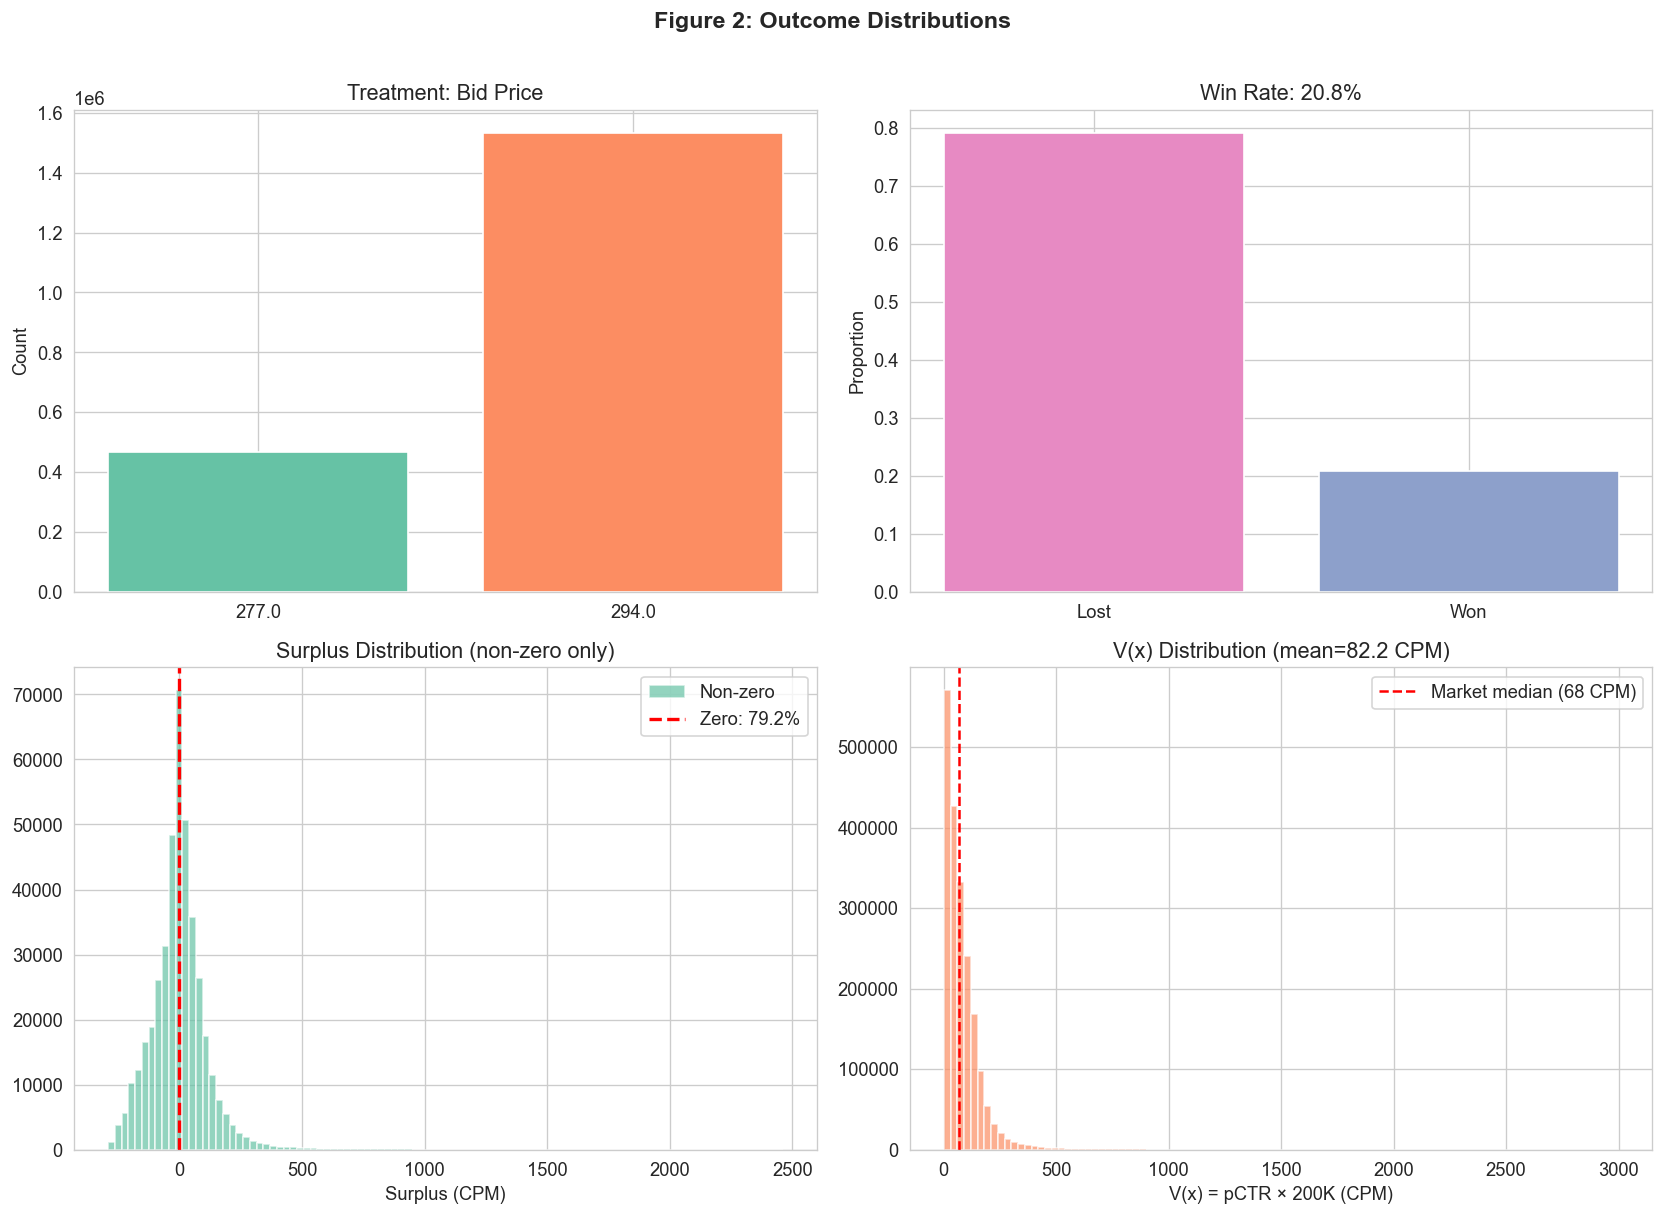

In [7]:
# --- Figure 2: Outcome Distributions ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# [0,0] Treatment distribution
bid_counts = pd.Series(data['T']).value_counts().sort_index()
axes[0, 0].bar(bid_counts.index.astype(str), bid_counts.values, color=PALETTE[:2])
axes[0, 0].set_title('Treatment: Bid Price')
axes[0, 0].set_ylabel('Count')

# [0,1] Win distribution
win_pct = [1 - data['Y_win'].mean(), data['Y_win'].mean()]
axes[0, 1].bar(['Lost', 'Won'], win_pct, color=[PALETTE[3], PALETTE[2]])
axes[0, 1].set_title(f"Win Rate: {data['Y_win'].mean():.1%}")
axes[0, 1].set_ylabel('Proportion')

# [1,0] Surplus distribution (point mass at 0 강조)
surplus = data['Y_surplus']
axes[1, 0].hist(surplus[surplus != 0], bins=100, color=PALETTE[0], alpha=0.7, label='Non-zero')
axes[1, 0].axvline(0, color='red', linestyle='--', linewidth=2, label=f'Zero: {(surplus==0).mean():.1%}')
axes[1, 0].set_title('Surplus Distribution (non-zero only)')
axes[1, 0].set_xlabel('Surplus (CPM)')
axes[1, 0].legend()

# [1,1] V(x) distribution
axes[1, 1].hist(data['values'], bins=100, color=PALETTE[1], alpha=0.7)
axes[1, 1].axvline(68, color='red', linestyle='--', label='Market median (68 CPM)')
axes[1, 1].set_title(f"V(x) Distribution (mean={data['values'].mean():.1f} CPM)")
axes[1, 1].set_xlabel('V(x) = pCTR × 200K (CPM)')
axes[1, 1].legend()

fig.suptitle('Figure 2: Outcome Distributions', fontsize=14, fontweight='bold', y=1.01)
fig.tight_layout()
fig.savefig(FIG_PATH / '09a_outcome_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 3: Win CATE (ForestDRLearner)

**ForestDRLearner** = Doubly Robust + Causal Forest.
- Propensity model P(T|X,W) + Outcome model E[Y|T,X,W] 결합
- Propensity가 극단적이어도 outcome model이 보완 (DR의 핵심 장점)
- `min_propensity` 클리핑으로 극단 weight 방지
- Exchange를 W에 포함하여 confounder로 통제

In [9]:
# --- ForestDRLearner Setup ---
# Exchange를 X에서 W로 이동 (bid=f(exchange) confounding 통제)
X_no_ex = data['X'][:, [0, 1, 3]]  # taxonomy, hour, region
W_aug = np.column_stack([data['W'], data['X'][:, 2:3]])  # W + exchange
feat_no_ex = ['advertiser_taxonomy', 'hour', 'region']

dr_model = ForestDRLearner(
    model_propensity=LGBMClassifier(n_estimators=200, num_leaves=31, verbose=-1, n_jobs=-1),
    model_regression=LGBMRegressor(n_estimators=200, num_leaves=31, verbose=-1, n_jobs=-1),
    min_propensity=0.01,       # clip extreme propensities
    n_estimators=500,
    honest=True,
    random_state=42,
)

# --- Win CATE ---
dr_model.fit(Y=data['Y_win'], T=data['T'], X=X_no_ex, W=W_aug)

t_vals = np.unique(data['T'])
cate_win = dr_model.effect(X_no_ex, T0=t_vals.min(), T1=t_vals.max()).flatten()
ci_win = dr_model.effect_interval(X_no_ex, T0=t_vals.min(), T1=t_vals.max(), alpha=0.05)
ate_win = float(dr_model.ate(X_no_ex, T0=t_vals.min(), T1=t_vals.max()))
ate_ci_win = dr_model.ate_interval(X_no_ex, T0=t_vals.min(), T1=t_vals.max(), alpha=0.05)

print(f"Win ATE (DR): {ate_win:.4f}")
print(f"  95% CI: [{float(ate_ci_win[0]):.4f}, {float(ate_ci_win[1]):.4f}]")
print(f"  해석: bid 277→294 시 win rate {ate_win*100:.2f}%p 변화")
print(f"\nCATE distribution:")
print(f"  mean={cate_win.mean():.4f}, std={cate_win.std():.4f}")
print(f"  min={cate_win.min():.4f}, max={cate_win.max():.4f}")
print(f"\nFeature importances: {dict(zip(feat_no_ex, dr_model.feature_importances_(T=t_vals.max())))}")

/opt/anaconda3/envs/rtb_ipinyou/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/rtb_ipinyou/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/rtb_ipinyou/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/rtb_ipinyou/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/rtb_ipinyou/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegre

Win ATE (DR): -0.0122
  95% CI: [-0.0328, 0.0084]
  해석: bid 277→294 시 win rate -1.22%p 변화

CATE distribution:
  mean=-0.0122, std=0.0169
  min=-0.1710, max=0.1298

Feature importances: {'advertiser_taxonomy': np.float64(0.08940796951627235), 'hour': np.float64(0.1897598912072248), 'region': np.float64(0.7208321392765028)}


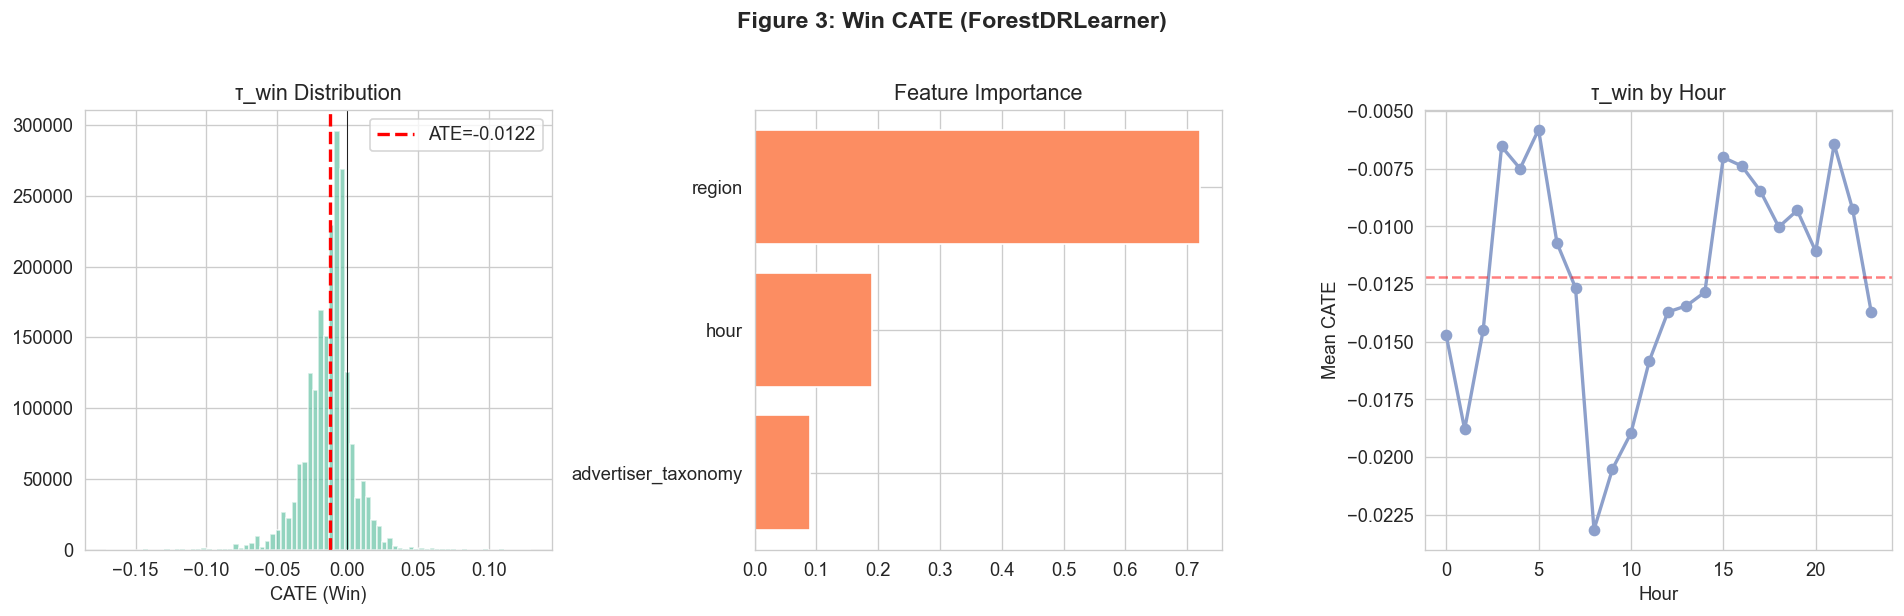

In [10]:
# --- Figure 3: Win CATE (ForestDRLearner) ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# [0] CATE distribution
axes[0].hist(cate_win, bins=80, color=PALETTE[0], alpha=0.7, edgecolor='white')
axes[0].axvline(ate_win, color='red', linestyle='--', linewidth=2, label=f'ATE={ate_win:.4f}')
axes[0].axvline(0, color='black', linewidth=0.5)
axes[0].set_title('τ_win Distribution')
axes[0].set_xlabel('CATE (Win)')
axes[0].legend()

# [1] Feature importance
imp = dr_model.feature_importances_(T=t_vals.max())
imp_df = pd.DataFrame({'feature': feat_no_ex, 'importance': imp}).sort_values('importance', ascending=True)
axes[1].barh(imp_df['feature'], imp_df['importance'], color=PALETTE[1])
axes[1].set_title('Feature Importance')

# [2] CATE by hour
hour_cate = pd.DataFrame({'hour': X_no_ex[:, 1], 'cate': cate_win})
hour_mean = hour_cate.groupby('hour')['cate'].mean()
axes[2].plot(hour_mean.index, hour_mean.values, 'o-', color=PALETTE[2], linewidth=2)
axes[2].axhline(ate_win, color='red', linestyle='--', alpha=0.5)
axes[2].set_title('τ_win by Hour')
axes[2].set_xlabel('Hour')
axes[2].set_ylabel('Mean CATE')

fig.suptitle('Figure 3: Win CATE (ForestDRLearner)', fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(FIG_PATH / '09a_cate_win_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 4: Payment & Click CATE

- τ_pay: winners-only, first-price 기계적 관계 (payment ≈ bid) 포함
- τ_click: bid→click 직접 효과 (예상: ~0, bid는 click에 영향 미미)

In [11]:
# --- Payment CATE (DR, winners-only) ---
X_won_no_ex = data['X_won'][:, [0, 1, 3]]
W_won_aug = np.column_stack([data['W_won'], data['X_won'][:, 2:3]])

dr_pay = ForestDRLearner(
    model_propensity=LGBMClassifier(n_estimators=200, num_leaves=31, verbose=-1, n_jobs=-1),
    model_regression=LGBMRegressor(n_estimators=200, num_leaves=31, verbose=-1, n_jobs=-1),
    min_propensity=0.01, n_estimators=500, honest=True, random_state=42,
)
t_won_vals = np.unique(data['T_won'])
dr_pay.fit(Y=data['Y_payment'], T=data['T_won'], X=X_won_no_ex, W=W_won_aug)
cate_pay = dr_pay.effect(X_won_no_ex, T0=t_won_vals.min(), T1=t_won_vals.max()).flatten()
ate_pay = float(dr_pay.ate(X_won_no_ex, T0=t_won_vals.min(), T1=t_won_vals.max()))

print(f"Payment ATE (DR): {ate_pay:.1f} CPM")
print(f"  First-price bid increment: {294-277} = 17 CPM")
print(f"  CATE: mean={cate_pay.mean():.1f}, std={cate_pay.std():.1f}")

# --- Click CATE (DR) ---
dr_click = ForestDRLearner(
    model_propensity=LGBMClassifier(n_estimators=200, num_leaves=31, verbose=-1, n_jobs=-1),
    model_regression=LGBMRegressor(n_estimators=200, num_leaves=31, verbose=-1, n_jobs=-1),
    min_propensity=0.01, n_estimators=500, honest=True, random_state=42,
)
dr_click.fit(Y=data['Y_click'], T=data['T'], X=X_no_ex, W=W_aug)
cate_click = dr_click.effect(X_no_ex, T0=t_vals.min(), T1=t_vals.max()).flatten()
ate_click = float(dr_click.ate(X_no_ex, T0=t_vals.min(), T1=t_vals.max()))

print(f"\nClick ATE (DR): {ate_click:.6f}")
print(f"  해석: bid→click 직접 효과 {'미미' if abs(ate_click) < 0.001 else '존재'}")

/opt/anaconda3/envs/rtb_ipinyou/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/rtb_ipinyou/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/rtb_ipinyou/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/rtb_ipinyou/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/rtb_ipinyou/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegre

Payment ATE (DR): 8.6 CPM
  First-price bid increment: 17 = 17 CPM
  CATE: mean=8.6, std=5.4


/opt/anaconda3/envs/rtb_ipinyou/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/rtb_ipinyou/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/rtb_ipinyou/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/rtb_ipinyou/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/rtb_ipinyou/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegre


Click ATE (DR): 0.000004
  해석: bid→click 직접 효과 미미


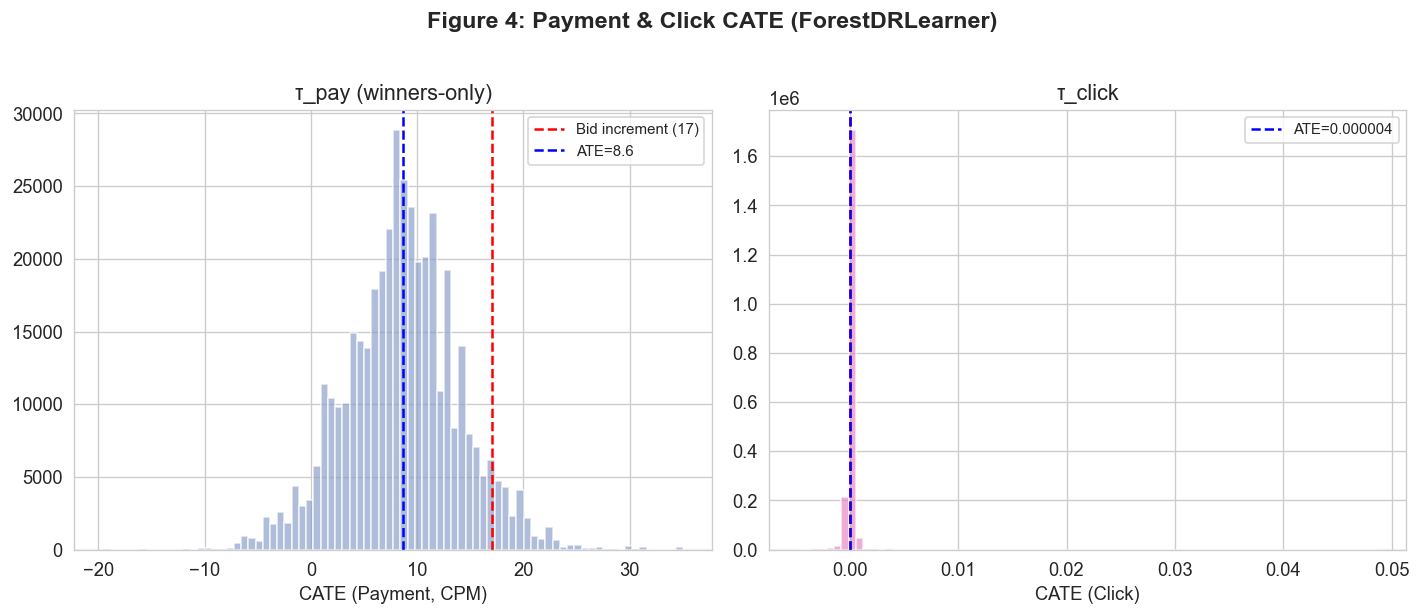

In [12]:
# --- Figure 4: Payment & Click CATE (DR) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(cate_pay, bins=80, color=PALETTE[2], alpha=0.7, edgecolor='white')
axes[0].axvline(17, color='red', linestyle='--', label='Bid increment (17)')
axes[0].axvline(ate_pay, color='blue', linestyle='--', label=f'ATE={ate_pay:.1f}')
axes[0].set_title('τ_pay (winners-only)')
axes[0].set_xlabel('CATE (Payment, CPM)')
axes[0].legend(fontsize=9)

axes[1].hist(cate_click, bins=80, color=PALETTE[3], alpha=0.7, edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].axvline(ate_click, color='blue', linestyle='--', label=f'ATE={ate_click:.6f}')
axes[1].set_title('τ_click')
axes[1].set_xlabel('CATE (Click)')
axes[1].legend(fontsize=9)

fig.suptitle('Figure 4: Payment & Click CATE (ForestDRLearner)', fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(FIG_PATH / '09a_cate_payment_click.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 5: Surplus CATE & Decomposition Validation

τ_surplus ≈ V(x) · τ_win − τ_pay (algebraic decomposition).
Direct surplus CATE vs decomposed → correlation으로 검증.

In [13]:
# --- Surplus CATE (DR) ---
dr_surplus = ForestDRLearner(
    model_propensity=LGBMClassifier(n_estimators=200, num_leaves=31, verbose=-1, n_jobs=-1),
    model_regression=LGBMRegressor(n_estimators=200, num_leaves=31, verbose=-1, n_jobs=-1),
    min_propensity=0.01, n_estimators=500, honest=True, random_state=42,
)
dr_surplus.fit(Y=data['Y_surplus'], T=data['T'], X=X_no_ex, W=W_aug)
cate_surplus = dr_surplus.effect(X_no_ex, T0=t_vals.min(), T1=t_vals.max()).flatten()
ate_surplus = float(dr_surplus.ate(X_no_ex, T0=t_vals.min(), T1=t_vals.max()))

print(f"Surplus ATE (DR): {ate_surplus:.2f} CPM")
print(f"  CATE: mean={cate_surplus.mean():.2f}, std={cate_surplus.std():.2f}")

# --- Decomposition ---
tau_pay_full = np.zeros_like(cate_win)
tau_pay_full[data['win_mask']] = cate_pay
tau_decomposed = data['values'] * cate_win - tau_pay_full

wm = data['win_mask']
if wm.sum() > 1:
    corr_d = float(np.corrcoef(cate_surplus[wm], tau_decomposed[wm])[0, 1])
    mae_d = float(np.mean(np.abs(cate_surplus[wm] - tau_decomposed[wm])))
else:
    corr_d, mae_d = float('nan'), float('nan')

print(f"\nDecomposition (winners-only): corr={corr_d:.3f}, MAE={mae_d:.1f}")

print(f"\n=== 4-Outcome ATE Summary (ForestDRLearner) ===")
print(f"  τ_win:     {ate_win:+.4f}")
print(f"  τ_pay:     {ate_pay:+.1f} CPM")
print(f"  τ_click:   {ate_click:+.6f}")
print(f"  τ_surplus: {ate_surplus:+.2f} CPM")

/opt/anaconda3/envs/rtb_ipinyou/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/rtb_ipinyou/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/rtb_ipinyou/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/rtb_ipinyou/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/rtb_ipinyou/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegre

Surplus ATE (DR): 0.16 CPM
  CATE: mean=0.16, std=2.26

Decomposition (winners-only): corr=0.388, MAE=10.0

=== 4-Outcome ATE Summary (ForestDRLearner) ===
  τ_win:     -0.0122
  τ_pay:     +8.6 CPM
  τ_click:   +0.000004
  τ_surplus: +0.16 CPM


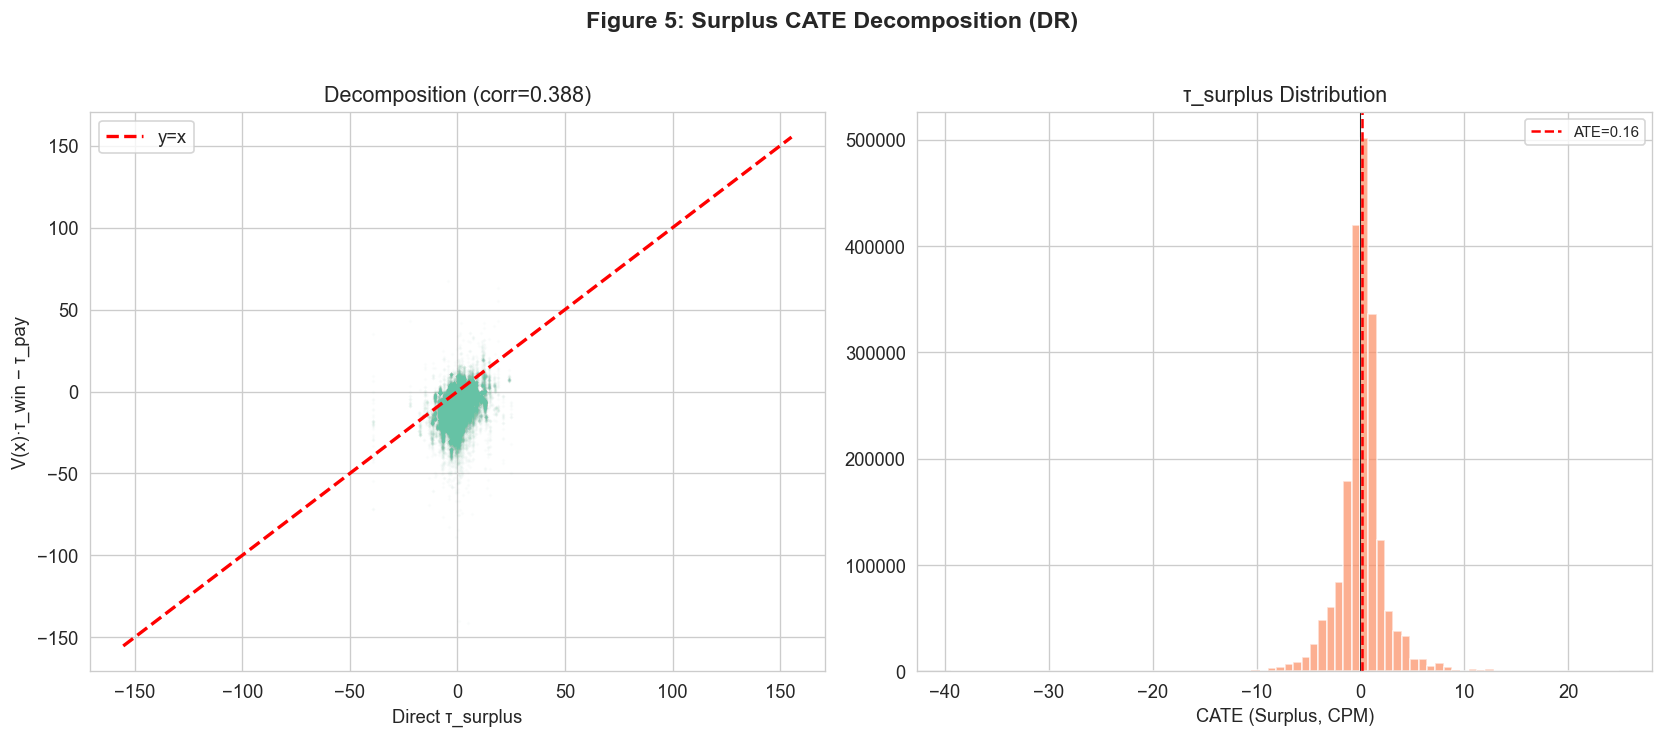

In [14]:
# --- Figure 5: Decomposition (DR) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

direct_won = cate_surplus[wm]
decomposed_won = tau_decomposed[wm]
axes[0].scatter(direct_won, decomposed_won, alpha=0.02, s=1, color=PALETTE[0])
lim = max(abs(direct_won).max(), abs(decomposed_won).max()) * 1.1
if lim > 0:
    axes[0].plot([-lim, lim], [-lim, lim], 'r--', linewidth=2, label='y=x')
axes[0].set_xlabel('Direct τ_surplus')
axes[0].set_ylabel('V(x)·τ_win − τ_pay')
axes[0].set_title(f'Decomposition (corr={corr_d:.3f})')
axes[0].legend()

axes[1].hist(cate_surplus, bins=80, color=PALETTE[1], alpha=0.7, edgecolor='white')
axes[1].axvline(ate_surplus, color='red', linestyle='--', label=f'ATE={ate_surplus:.2f}')
axes[1].axvline(0, color='black', linewidth=0.5)
axes[1].set_title('τ_surplus Distribution')
axes[1].set_xlabel('CATE (Surplus, CPM)')
axes[1].legend(fontsize=9)

fig.suptitle('Figure 5: Surplus CATE Decomposition (DR)', fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(FIG_PATH / '09a_decomposition_validation.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 6: Mediation — Volume vs Cost Channel

- **NIE (Volume)**: E[V(x) · τ_win(x)] — 더 많이 이겨서 얻는 surplus
- **NDE (Cost)**: Total − NIE — 더 많이 내서 잃는 surplus
- Algebraic decomposition (Pearl의 formal NDE/NIE가 아닌 structural identity)

In [15]:
# --- Mediation (DR) ---
nie = float(np.mean(data['values'] * cate_win))
total = ate_surplus
nde = total - nie

print(f"Total effect:  {total:.2f} CPM")
print(f"NIE (volume):  {nie:.2f} CPM")
print(f"NDE (cost):    {nde:.2f} CPM")
if abs(total) > 1e-10:
    print(f"NIE proportion: {nie/total*100:.1f}%")

taxonomy = data['taxonomy']
med_records = []
for seg in ['branding', 'retargeting', 'mixed']:
    seg_mask = taxonomy == seg
    if seg_mask.sum() == 0:
        continue
    seg_nie = float(np.mean(data['values'][seg_mask] * cate_win[seg_mask]))
    seg_total = float(np.mean(cate_surplus[seg_mask]))
    seg_nde = seg_total - seg_nie
    med_records.append({'taxonomy': seg, 'NIE': seg_nie, 'NDE': seg_nde,
                        'Total': seg_total, 'n': int(seg_mask.sum())})
    print(f"\n{seg} (n={seg_mask.sum():,}): NIE={seg_nie:.2f}, NDE={seg_nde:.2f}, Total={seg_total:.2f}")

med_df = pd.DataFrame(med_records)

Total effect:  0.16 CPM
NIE (volume):  -1.00 CPM
NDE (cost):    1.16 CPM
NIE proportion: -638.1%

branding (n=496,723): NIE=-1.36, NDE=1.07, Total=-0.29

retargeting (n=1,503,277): NIE=-0.88, NDE=1.19, Total=0.30


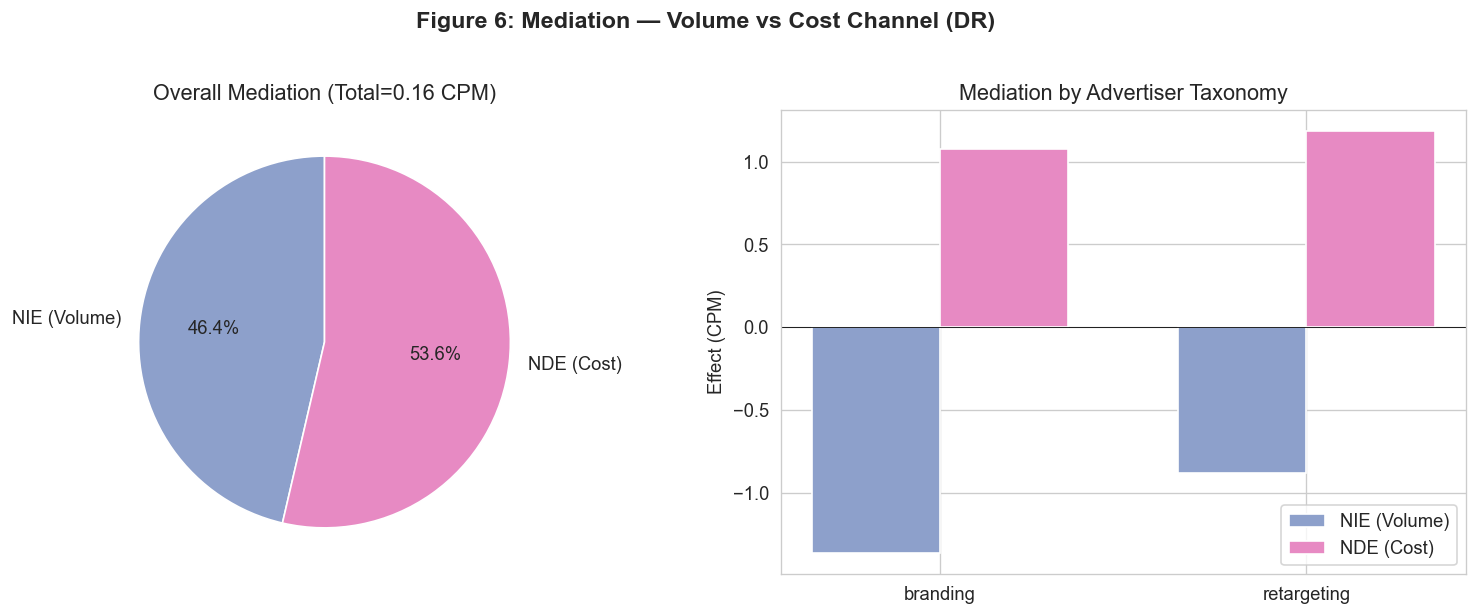

In [17]:
# --- Figure 6: Mediation NIE/NDE (DR) ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# [0] Overall mediation pie
labels = ['NIE (Volume)', 'NDE (Cost)']
sizes = [abs(nie), abs(nde)]
colors_med = [PALETTE[2], PALETTE[3]]
axes[0].pie(sizes, labels=labels, colors=colors_med, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 11})
axes[0].set_title(f'Overall Mediation (Total={total:.2f} CPM)')

# [1] Segment-level stacked bar
if len(med_df) > 0:
    x = np.arange(len(med_df))
    w = 0.35
    axes[1].bar(x - w/2, med_df['NIE'], w, label='NIE (Volume)', color=PALETTE[2])
    axes[1].bar(x + w/2, med_df['NDE'], w, label='NDE (Cost)', color=PALETTE[3])
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(med_df['taxonomy'])
    axes[1].set_ylabel('Effect (CPM)')
    axes[1].set_title('Mediation by Advertiser Taxonomy')
    axes[1].legend()
    axes[1].axhline(0, color='black', linewidth=0.5)

fig.suptitle('Figure 6: Mediation — Volume vs Cost Channel (DR)',
             fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(FIG_PATH / '09a_mediation_nie_nde.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 7: Segment CATE Heatmap

Exchange × Hour × Advertiser taxonomy 다차원 heterogeneity 분석.

In [19]:
# --- Segment CATE summary (DR) ---
# Build pseudo-CATEResult for segment summary (full-sample outcomes only)
from src.causal.cate import CATEResult

dr_results = {}
for name, cate_arr in [('win', cate_win), ('surplus', cate_surplus)]:
    dr_results[name] = CATEResult(
        outcome_name=name, cate=cate_arr,
        cate_ci_lower=cate_arr, cate_ci_upper=cate_arr,
        ate=float(np.mean(cate_arr)), ate_ci=(0.0, 0.0),
        feature_importances=np.array([]), feature_names=feat_no_ex, n_samples=len(cate_arr),
    )

summary = compute_segment_cate_summary(dr_results, taxonomy, 'advertiser_taxonomy')
display(summary.pivot_table(index='advertiser_taxonomy', columns='outcome',
                            values='mean_cate', aggfunc='first').round(4))

outcome,surplus,win
advertiser_taxonomy,,
branding,-0.2898,-0.0153
retargeting,0.3044,-0.0112


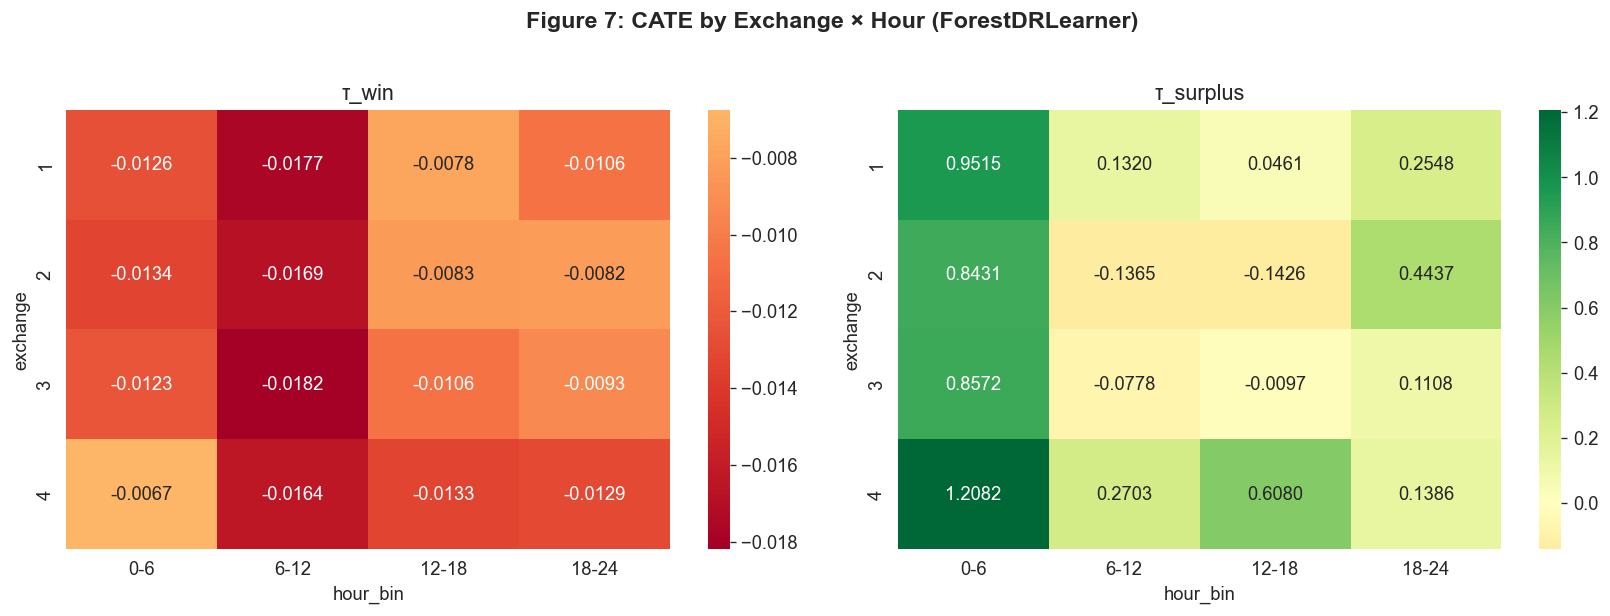

In [20]:
# --- Figure 7: Segment CATE Heatmap (DR) ---
hour_col = X_no_ex[:, 1]
ex_col = W_aug[:, -1]
hour_bin = pd.cut(hour_col, bins=[0, 6, 12, 18, 24], labels=['0-6', '6-12', '12-18', '18-24'])

seg_df = pd.DataFrame({
    'exchange': ex_col.astype(int), 'hour_bin': hour_bin,
    'tau_win': cate_win, 'tau_surplus': cate_surplus,
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in [(axes[0], 'tau_win', 'τ_win'), (axes[1], 'tau_surplus', 'τ_surplus')]:
    pivot = seg_df.pivot_table(index='exchange', columns='hour_bin', values=col, aggfunc='mean')
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='RdYlGn', center=0, ax=ax)
    ax.set_title(title)

fig.suptitle('Figure 7: CATE by Exchange × Hour (ForestDRLearner)', fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(FIG_PATH / '09a_segment_cate_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 8: Simulation Counterfactual Comparison

Model-based counterfactual: bid를 연속적으로 조작하여 surplus 변화 탐색.
CATE 방향성과 simulation 결과의 일치 여부 검증.

In [21]:
# --- Counterfactual scenarios (won-only) ---
from src.causal.scm import simulate_counterfactual_scenarios

won_mask_full = test_filtered['win'] == 1
won_df = test_filtered[won_mask_full].reset_index(drop=True)
won_preds = {k: np.asarray(v)[won_mask_full.values] for k, v in preds_filtered.items()}

market_prices = won_df['payprice'].values.astype(float)
original_bids = won_df['bidprice'].values.astype(float)
clicks = won_df['click'].values.astype(np.int32)
values_won = compute_impression_values(won_preds['p_ctr']).values

cf_df = simulate_counterfactual_scenarios(
    market_prices, original_bids, values_won, clicks,
    multipliers=[0.7, 0.8, 0.9, 0.95, 1.0, 1.05, 1.1, 1.2, 1.3],
)
display(cf_df.round(4))

,multiplier,scenario,win_rate,total_surplus,avg_surplus_per_win,overpayment_ratio,delta_surplus,delta_win_rate
0,0.70,bid×0.70,0.9009,-3.695582e+08,-113.5792,7.2926,3.484998e+08,-0.0991
1,0.80,bid×0.80,0.9369,-4.797833e+08,-141.7908,8.1534,2.382747e+08,-0.0631
2,0.90,bid×0.90,0.9659,-5.952629e+08,-170.6436,9.0200,1.227950e+08,-0.0341
3,0.95,bid×0.95,0.9798,-6.547059e+08,-185.0109,9.4404,6.335207e+07,-0.0202
4,1.00,bid×1.00,1.0000,-7.180580e+08,-198.8215,9.7888,0.000000e+00,0.0000
5,1.05,bid×1.05,1.0000,-7.702578e+08,-213.2749,10.3283,-5.219980e+07,0.0000
6,1.10,bid×1.10,1.0000,-8.224576e+08,-227.7284,10.8677,-1.043996e+08,0.0000
7,1.20,bid×1.20,1.0000,-9.268572e+08,-256.6354,11.9466,-2.087992e+08,0.0000
8,1.30,bid×1.30,1.0000,-1.031257e+09,-285.5424,13.0255,-3.131988e+08,0.0000


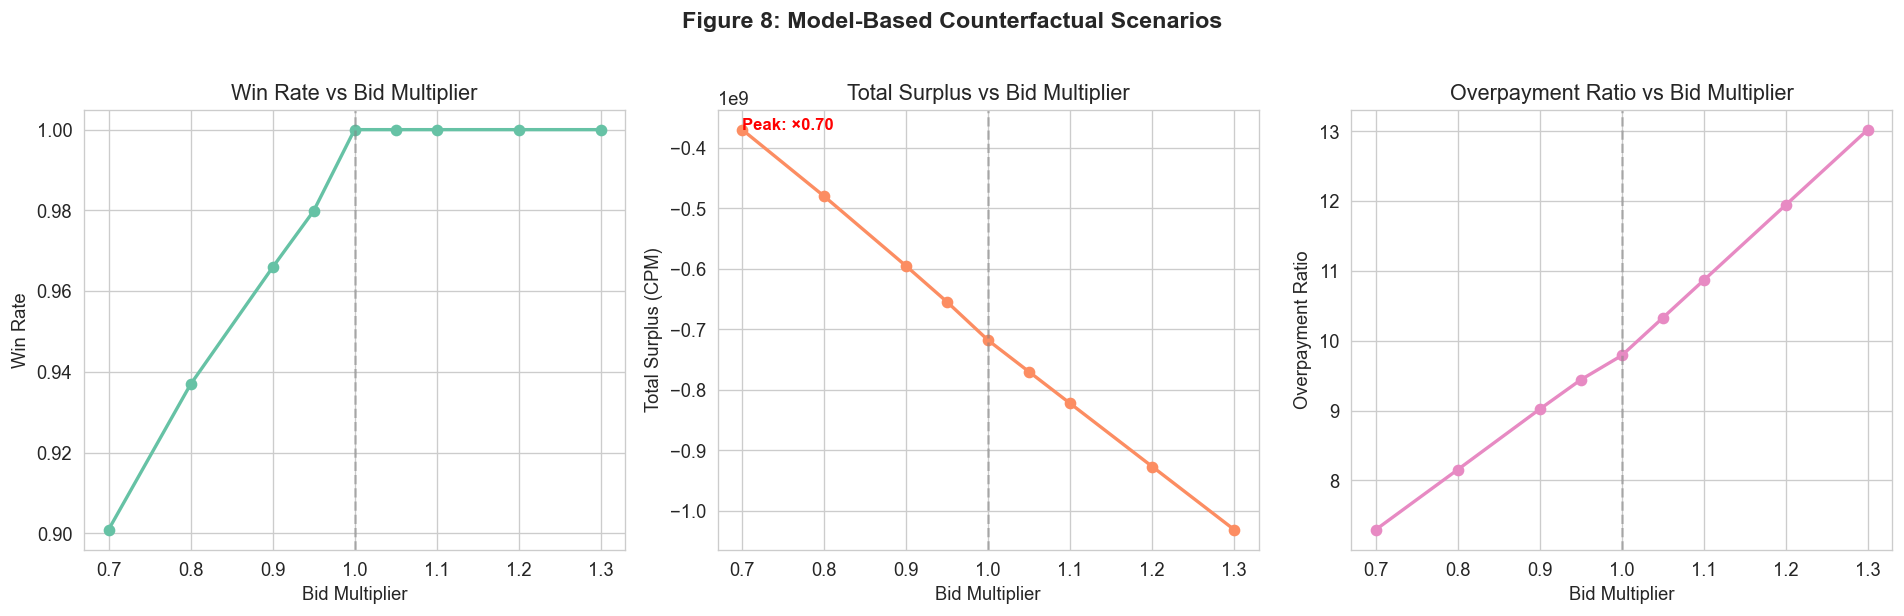

In [22]:
# --- Figure 8: Counterfactual Scenarios ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(cf_df['multiplier'], cf_df['win_rate'], 'o-', color=PALETTE[0], linewidth=2)
axes[0].axvline(1.0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title('Win Rate vs Bid Multiplier')
axes[0].set_xlabel('Bid Multiplier')
axes[0].set_ylabel('Win Rate')

axes[1].plot(cf_df['multiplier'], cf_df['total_surplus'], 'o-', color=PALETTE[1], linewidth=2)
axes[1].axvline(1.0, color='gray', linestyle='--', alpha=0.5)
peak_idx = cf_df['total_surplus'].idxmax()
axes[1].annotate(f"Peak: ×{cf_df.loc[peak_idx, 'multiplier']:.2f}",
                 (cf_df.loc[peak_idx, 'multiplier'], cf_df.loc[peak_idx, 'total_surplus']),
                 fontsize=10, fontweight='bold', color='red')
axes[1].set_title('Total Surplus vs Bid Multiplier')
axes[1].set_xlabel('Bid Multiplier')
axes[1].set_ylabel('Total Surplus (CPM)')

axes[2].plot(cf_df['multiplier'], cf_df['overpayment_ratio'], 'o-', color=PALETTE[3], linewidth=2)
axes[2].axvline(1.0, color='gray', linestyle='--', alpha=0.5)
axes[2].set_title('Overpayment Ratio vs Bid Multiplier')
axes[2].set_xlabel('Bid Multiplier')
axes[2].set_ylabel('Overpayment Ratio')

fig.suptitle('Figure 8: Model-Based Counterfactual Scenarios',
             fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(FIG_PATH / '09a_counterfactual_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 9: CATE → Bidding Insight

고-τ_surplus 세그먼트 식별 → bid 전략 차별화 근거.

In [23]:
# --- CATE → Bidding insight (DR) ---
tau = cate_surplus
q25, q75 = np.percentile(tau, [25, 75])

print("=== Surplus CATE Quartiles (ForestDRLearner) ===")
print(f"  Q25={q25:.2f}, Median={np.median(tau):.2f}, Q75={q75:.2f}")
print(f"  High-CATE: {(tau > q75).sum():,}, Low-CATE: {(tau < q25).sum():,}")

high_mask = tau > q75
low_mask = tau < q25
seg_df_full = pd.DataFrame({
    'exchange': W_aug[:, -1], 'hour': X_no_ex[:, 1],
    'taxonomy': taxonomy,
    'group': np.where(high_mask, 'High τ', np.where(low_mask, 'Low τ', 'Mid')),
})

for group in ['High τ', 'Low τ']:
    gdf = seg_df_full[seg_df_full['group'] == group]
    print(f"\n{group} (n={len(gdf):,}):")
    print(f"  Exchange: {gdf['exchange'].astype(int).value_counts().sort_index().to_dict()}")
    print(f"  Taxonomy: {gdf['taxonomy'].value_counts().to_dict()}")

=== Surplus CATE Quartiles (ForestDRLearner) ===
  Q25=-0.66, Median=0.29, Q75=1.07
  High-CATE: 484,802, Low-CATE: 497,325

High τ (n=484,802):
  Exchange: {1: 110202, 2: 110428, 3: 199981, 4: 64191}
  Taxonomy: {'retargeting': 344360, 'branding': 140442}

Low τ (n=497,325):
  Exchange: {1: 105223, 2: 112418, 3: 225156, 4: 54528}
  Taxonomy: {'retargeting': 280501, 'branding': 216824}


## Section 10: Limitations & Discussion

### Identification Limitations

1. **Binary treatment**: S3에서 bid = {277, 294} only → ~6% increment 효과만 추정 가능
2. **Cross-advertiser confounding**: Advertiser identity가 bid와 부분 confounded
   - 통제: advertiser_taxonomy를 X에 포함
   - 한계: unobserved advertiser-specific factors (creative quality, targeting)
3. **Temporal limitation**: S3 (2013-10) 단일 시점, 시장 변화 미반영
4. **Point mass at 0**: Surplus의 76%가 0 (lost bids) → 분해 접근으로 완화
5. **Collider bias**: Payment CATE는 win=1 조건부 → bid↔market_price spurious association 가능

### V(x)가 CATE Outcome이 될 수 없는 이유

- V(x) = pCTR × CPC_target — bid에 의존하지 않음 (∂V/∂bid = 0)
- 모델 예측값이지 관측된 outcome이 아님 → 순환 논리
- V(x)의 올바른 역할: surplus 분해의 상수 (τ_surplus ≈ V·τ_win - τ_pay)

### Practical Recommendations

1. **Production**: Simulation counterfactual (Section 8) > CATE (이 데이터셋 한정)
2. **Segment prioritization**: CATE로 고-surplus 세그먼트 식별 → 시뮬레이션 검증
3. **A/B test**: Causal claim 검증은 반드시 online experiment으로
4. **일반화**: 실제 RTB 환경에서는 연속 bid → 이 CATE 프레임워크 직접 적용 가능.
   iPinYou flat-bid은 **데이터** 한계이지 **방법론** 한계가 아님.